In this section , we will discover how data is distrubuted  and how it will impact your models downstream.

General all majority of the data follow normal distribution. We can say that the data is normal distributed when 68% of the data lies within 1 standard deviation and 99% lies within 2 standard deviation. we can use matplotlib and plot a histogram to observe the data distribution.

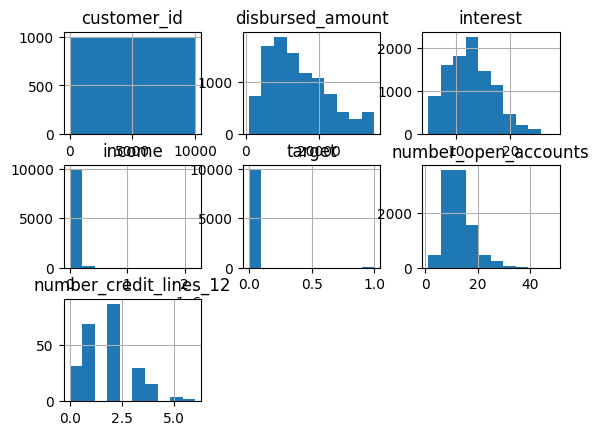

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv('data/loans.csv')
df.hist()
plt.show()

In [6]:
df.columns

Index(['customer_id', 'disbursed_amount', 'interest', 'market', 'employment',
       'time_employed', 'householder', 'income', 'date_issued', 'target',
       'loan_purpose', 'number_open_accounts', 'date_last_payment',
       'number_credit_lines_12'],
      dtype='object')

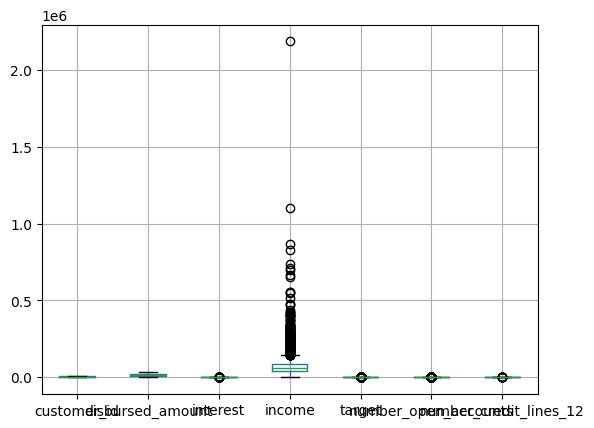

In [8]:
df.boxplot()
plt.show()

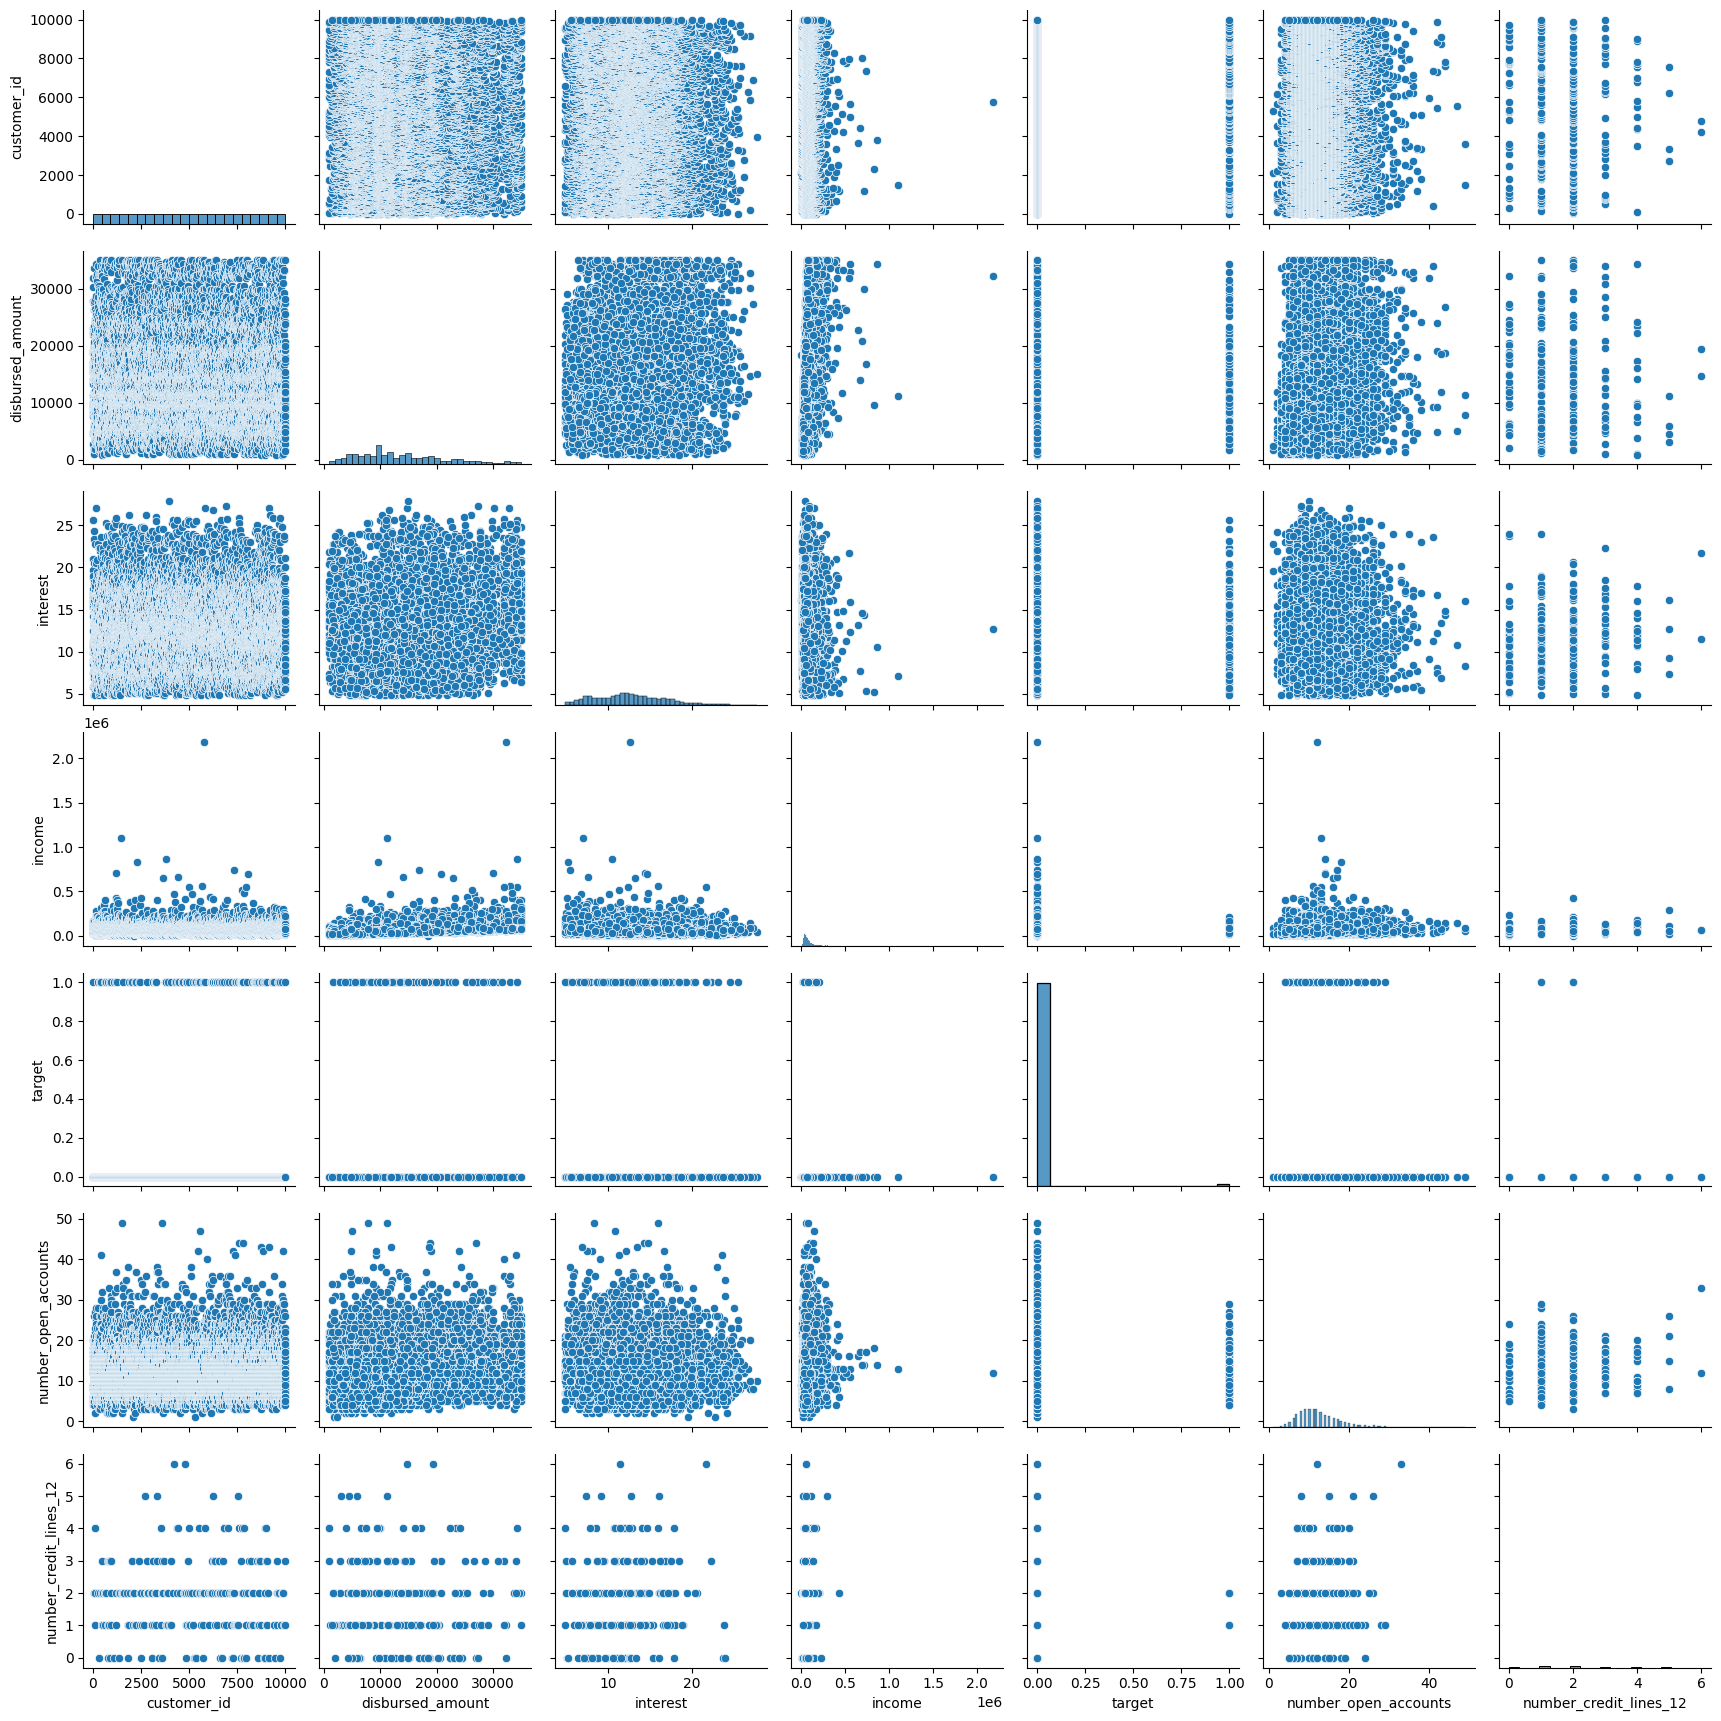

In [9]:
import seaborn as sns
sns.pairplot(df)

We can use `df.describe()` to get overall statistics of the data.

In [10]:
df.describe()

,customer_id,disbursed_amount,interest,income,target,number_open_accounts,number_credit_lines_12
count,10000.00000,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.000000,238.000000
mean,4999.50000,14132.275500,12.678819,7.157229e+04,0.011700,12.516300,1.785714
std,2886.89568,8058.310311,4.214989,5.286105e+04,0.107537,5.402615,1.197873
min,0.00000,910.000000,4.841200,0.000000e+00,0.000000,1.000000,0.000000
25%,2499.75000,7840.000000,9.490000,4.365000e+04,0.000000,9.000000,1.000000
50%,4999.50000,12375.000000,12.396900,6.045000e+04,0.000000,12.000000,2.000000
75%,7499.25000,19200.000000,15.475500,8.536000e+04,0.000000,15.000000,2.000000
max,9999.00000,35000.000000,27.880000,2.185000e+06,1.000000,49.000000,6.000000


### Scaling and transformations:

One of the most important topics that we come across is how certain type of data are distributed. Sometime we need to make these data be based on the same range scale. This can be done in many ways but for this section we will use `Min-Max Scalling` and `Normalization/Standardization`.

`Min-Max scalling`  is as the name suggests scalling of data by taking max and minmum values of the given data. In this values will change but distrbution will not.


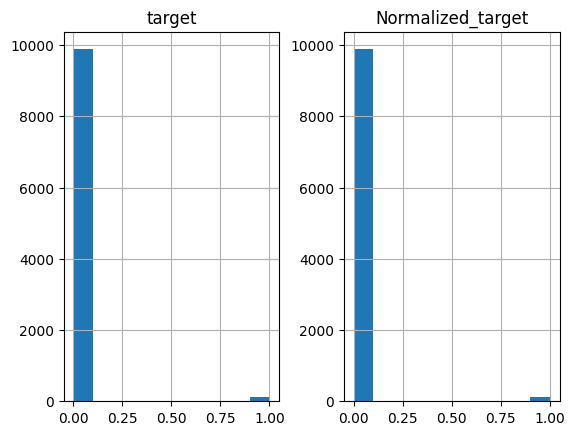

In [ ]:
from sklearn.preprocessing import MinMaxScaler


scaler = MinMaxScaler()

scaler.fit(df[['target']])

df['Normalized_target'] = scaler.transform(df[['target']])
df[['target','Normalized_target']].hist()
plt.show()

`Standardization` finds the mean of the data and centers the data around it. Then we scale data around the mean. This technnically has not maximum and minimum values .

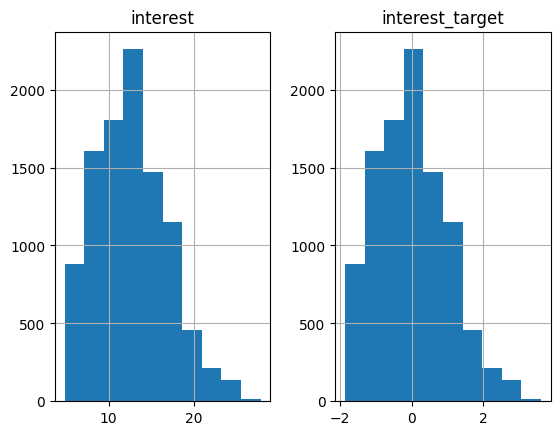

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(df[['interest']])

df['interest_target'] = scaler.transform(df[['interest']])
df[['interest','interest_target']].hist()
plt.show()

`Log Transformation` on the other hand can be used to make highly skewed distributions less skewed.

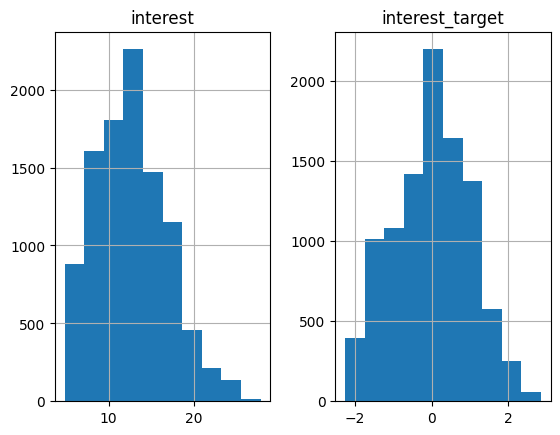

In [16]:
from sklearn.preprocessing import PowerTransformer

scaler = PowerTransformer()

scaler.fit(df[['interest']])

df['interest_target'] = scaler.transform(df[['interest']])
df[['interest','interest_target']].hist()
plt.show()

### Removing outliers

Outliners are data points that exist far away from majority of your data. This occurs due to incorrect data recording. For removing outliners, we can following approaches:

1. `Qunatile Based Detection`: In this method we remove only the outliners quantile part of the data.

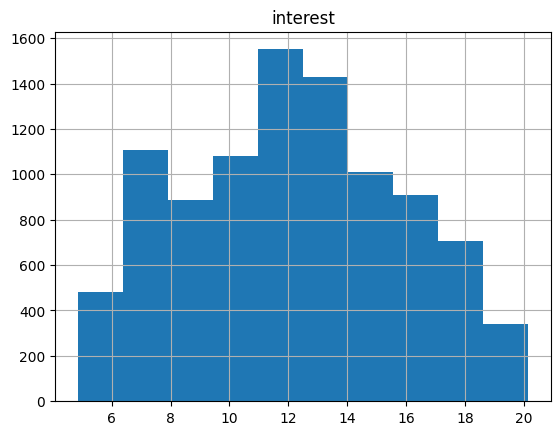

In [21]:
q_cutoff = df['interest'].quantile(0.95)

mask = df['interest'] < q_cutoff

trimmder_df = df[mask]
trimmder_df[['interest']].hist()
plt.show()

2.`Standard Deviation based detection`: We eleminate data based on the mean and standard deviation

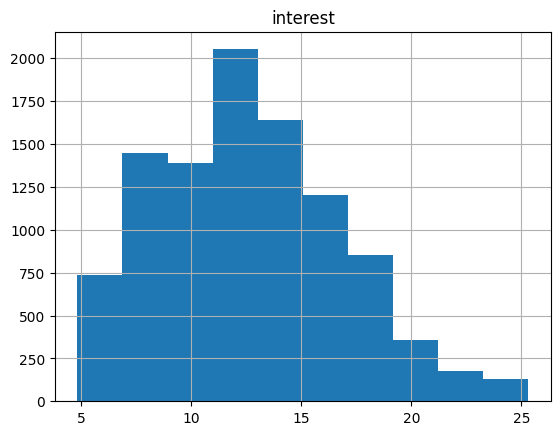

In [22]:
mean = df['interest'].mean()
std = df['interest'].std()

q_cutoff = std * 3

lower, upper = mean- q_cutoff, mean + q_cutoff
new_df = df[(df['interest'] < upper) &((df['interest'] > lower))]
new_df[['interest']].hist()
plt.show()